# FIFA Players and Statistics

#### CMSC320 Spring 2026 Final Project
by Alex, William, Tyler, Elliot, Aashrith

## Contributions
| Member | Sections | 1-2 Sentence Summary |
| :--- | :--- | :--- |
| **Alex** | A, B, C, D, E | Proposed the initial idea, dataset preprocessing & curation, algorithm development and training|
| **Aashrith** | A, C, F, G | Project brainstorming, summary statistics, conclusion and final report creation |
| **Elliott** | A, C, E, F | Project brainstorming, test data analytics, result analysis |
| **Tyler** | A, C, D, E, F | Project brainstorming, ML Alg design, Ml Alg training, Conclusion |
| **Will** | A, C, E, F, G | Project brainstorming, ML Alg training, visualization, tutorial creation and publishing |

## Table of Contents
- [Introduction](#a) — Motivation for the project and the research questions guiding our analysis.
- [Data Curation and Initial Exploration](#b) — Overview of the FIFA 21 dataset, cleaning steps, and initial exploration of player attributes.
- [Data Exploration & Analysis](#c) — Statistical tests and visualizations addressing each of our research questions on height, stamina, footedness, and position.
- [ML Algorithm Design/Development](#d) — Preparing datasets and features to be considered by model
- [ML Training, Testing, and Analysis](#e) — Building and testing a classification model to predict a player's best position from their attributes.
- [Identifying the Most Important Coefficients](#f) — Interpreting model coefficients and feature importance to determine which attributes most influence position prediction.
- [Insights and Conclusions](#g) — Summary of findings, limitations, and directions for future work.

<a id="a"></a>
## Introduction

The field of sports analytics has undergone a massive transformation in recent decades, evolving from a niche interest to a billion dollar industry dictating recruitment, development and financial investment. As a group, our shared passion for sports led us to the FIFA 21 Dataset, containing comprehensive statistics for over 18,000 players.

Our research is centered around a few essential questions:

* To what extent does a player's height influence their technical heading skills?
* Does a player's stamina decline significantly as they age?
* Is there a statistically significant difference in the overall ratings of players based on their preferred foot?
* Can a player's skills/attributes alone predict their best position?

Answering these questions matters for a few reasons.
First, they reflect real decisions clubs make every day about recruitment, training, and player development, where grounding judgments in data reduces costly mistakes.
Second, they test conventional wisdom about height, age, and footedness that is repeated constantly but rarely examined rigorously.
Third, predicting a player's best position from their attributes has practical use for helping clubs deploy young players where they're most likely to succeed.
Finally, the methods used here mirror those in professional sports analytics, showing how data science can turn long-standing debates into testable questions.



<a id="b"></a>
## Data Curation and Initial Exploration <a id="b"></a>

[Here](https://www.kaggle.com/datasets/yagunnersya/fifa-21-messy-raw-dataset-for-cleaning-exploring) is the FIFA 21 dataset that we are using to answer our research questions. Special thanks to Rachit Toshniwal for creating this dataset! This dataset contains all players that were in the FIFA 2021 game made by EA Sports. It includes many attributes of the players, such as rating, height, age, etc. This data is curated by the FC Data Collective, a group of 6,000 people who analyze and report on soccer players. EA Sports also employs a team of pressionals to refine the final ratings that are in this dataset.

In this section we will load in our data, handle missing or erroneous entries,  and transform columns to more useful types/formats.

#### Imports
To start we import any necessary packages along with our relevant dataset

In [70]:
# import packages
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# import dataset
df = pd.read_csv("fifa21 raw data v2.csv", low_memory=False)
display(df.head())

,ID,Name,LongName,photoUrl,playerUrl,Nationality,Age,↓OVA,POT,Club,Contract,Positions,Height,Weight,Preferred Foot,BOV,Best Position,Joined,Loan Date End,Value,Wage,Release Clause,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Skill,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Movement,Acceleration,Sprint Speed,Agility,Reactions,Balance,Power,Shot Power,Jumping,Stamina,Strength,Long Shots,Mentality,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Defending,Marking,Standing Tackle,Sliding Tackle,Goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total Stats,Base Stats,W/F,SM,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,158023,L. Messi,Lionel Messi,https://cdn.sofifa.com/players/158/023/21_60.png,http://sofifa.com/player/158023/lionel-messi/210006/,Argentina,33,93,93,\n\n\n\nFC Barcelona,2004 ~ 2021,"RW, ST, CF",170cm,72kg,Left,93,RW,"Jul 1, 2004",NaN,€103.5M,€560K,€138.4M,429,85,95,70,91,88,470,96,93,94,91,96,451,91,80,91,94,95,389,86,68,72,69,94,347,44,40,93,95,75,96,91,32,35,24,54,6,11,15,14,8,2231,466,4 ★,4★,Medium,Low,5 ★,85,92,91,95,38,65,771
1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,https://cdn.sofifa.com/players/020/801/21_60.png,http://sofifa.com/player/20801/c-ronaldo-dos-santos-aveiro/210006/,Portugal,35,92,92,\n\n\n\nJuventus,2018 ~ 2022,"ST, LW",187cm,83kg,Right,92,ST,"Jul 10, 2018",NaN,€63M,€220K,€75.9M,437,84,95,90,82,86,414,88,81,76,77,92,431,87,91,87,95,71,444,94,95,84,78,93,353,63,29,95,82,84,95,84,28,32,24,58,7,11,15,14,11,2221,464,4 ★,5★,High,Low,5 ★,89,93,81,89,35,77,562
2,200389,J. Oblak,Jan Oblak,https://cdn.sofifa.com/players/200/389/21_60.png,http://sofifa.com/player/200389/jan-oblak/210006/,Slovenia,27,91,93,\n\n\n\nAtlético Madrid,2014 ~ 2023,GK,188cm,87kg,Right,91,GK,"Jul 16, 2014",NaN,€120M,€125K,€159.4M,95,13,11,15,43,13,109,12,13,14,40,30,307,43,60,67,88,49,268,59,78,41,78,12,140,34,19,11,65,11,68,57,27,12,18,437,87,92,78,90,90,1413,489,3 ★,1★,Medium,Medium,3 ★,87,92,78,90,52,90,150
3,192985,K. De Bruyne,Kevin De Bruyne,https://cdn.sofifa.com/players/192/985/21_60.png,http://sofifa.com/player/192985/kevin-de-bruyne/210006/,Belgium,29,91,91,\n\n\n\nManchester City,2015 ~ 2023,"CAM, CM",181cm,70kg,Right,91,CAM,"Aug 30, 2015",NaN,€129M,€370K,€161M,407,94,82,55,94,82,441,88,85,83,93,92,398,77,76,78,91,76,408,91,63,89,74,91,408,76,66,88,94,84,91,186,68,65,53,56,15,13,5,10,13,2304,485,5 ★,4★,High,High,4 ★,76,86,93,88,64,78,207
4,190871,Neymar Jr,Neymar da Silva Santos Jr.,https://cdn.sofifa.com/players/190/871/21_60.png,http://sofifa.com/player/190871/neymar-da-silva-santos-jr/210006/,Brazil,28,91,91,\n\n\n\nParis Saint-Germain,2017 ~ 2022,"LW, CAM",175cm,68kg,Right,91,LW,"Aug 3, 2017",NaN,€132M,€270K,€166.5M,408,85,87,62,87,87,448,95,88,89,81,95,453,94,89,96,91,83,357,80,62,81,50,84,356,51,36,87,90,92,93,94,35,30,29,59,9,9,15,15,11,2175,451,5 ★,5★,High,Medium,5 ★,91,85,86,94,36,59,595


#### Clean Dataset
Next we clean the dataset in order to make the dataset easier to work with. This includes:
* Converting height to a standard measurement
* Converting weight to a standard measurement
* Changing the data types of certain columns
* Removing noise and random characters from columns




In [71]:
# Convert Height to centimeters
display(df["Height"].unique())

def convert_height(value):
  if pd.isna(value):
    return np.nan

  elif "cm" in value:
    return int(value.replace("cm", ""))
  else:
    h = value.split("'")
    feet = int(h[0])
    inches = int(h[1].replace('"', ""))
    return round((feet * 30.48) + (inches * 2.54), 2)

df["Height"] = df["Height"].apply(convert_height)

display(df["Height"].unique())



array(['170cm', '187cm', '188cm', '181cm', '175cm', '184cm', '191cm',
       '178cm', '193cm', '185cm', '199cm', '173cm', '168cm', '176cm',
       '177cm', '183cm', '180cm', '189cm', '179cm', '195cm', '172cm',
       '182cm', '186cm', '192cm', '165cm', '194cm', '167cm', '196cm',
       '163cm', '190cm', '174cm', '169cm', '171cm', '197cm', '200cm',
       '166cm', '6\'2"', '164cm', '198cm', '6\'3"', '6\'5"', '5\'11"',
       '6\'4"', '6\'1"', '6\'0"', '5\'10"', '5\'9"', '5\'6"', '5\'7"',
       '5\'4"', '201cm', '158cm', '162cm', '161cm', '160cm', '203cm',
       '157cm', '156cm', '202cm', '159cm', '206cm', '155cm'], dtype=object)

array([170.  , 187.  , 188.  , 181.  , 175.  , 184.  , 191.  , 178.  ,
       193.  , 185.  , 199.  , 173.  , 168.  , 176.  , 177.  , 183.  ,
       180.  , 189.  , 179.  , 195.  , 172.  , 182.  , 186.  , 192.  ,
       165.  , 194.  , 167.  , 196.  , 163.  , 190.  , 174.  , 169.  ,
       171.  , 197.  , 200.  , 166.  , 187.96, 164.  , 198.  , 190.5 ,
       195.58, 180.34, 193.04, 185.42, 182.88, 177.8 , 175.26, 167.64,
       170.18, 162.56, 201.  , 158.  , 162.  , 161.  , 160.  , 203.  ,
       157.  , 156.  , 202.  , 159.  , 206.  , 155.  ])

In [72]:
# Convert Weight to pounds
display(df["Weight"].unique())

def convert_weight(value):
  if "lbs" in value:
    return int(value.replace("lbs", ""))
  else:
    return round(int(value.replace("kg", ""))*2.20462, 2)

df["Weight"] = df["Weight"].apply(convert_weight)
display(df["Weight"].unique())

array(['72kg', '83kg', '87kg', '70kg', '68kg', '80kg', '71kg', '91kg',
       '73kg', '85kg', '92kg', '69kg', '84kg', '96kg', '81kg', '82kg',
       '75kg', '86kg', '89kg', '74kg', '76kg', '64kg', '78kg', '90kg',
       '66kg', '60kg', '94kg', '79kg', '67kg', '65kg', '59kg', '61kg',
       '93kg', '88kg', '97kg', '77kg', '62kg', '63kg', '95kg', '100kg',
       '58kg', '183lbs', '179lbs', '172lbs', '196lbs', '176lbs', '185lbs',
       '170lbs', '203lbs', '168lbs', '161lbs', '146lbs', '130lbs',
       '190lbs', '174lbs', '148lbs', '165lbs', '159lbs', '192lbs',
       '181lbs', '139lbs', '154lbs', '157lbs', '163lbs', '98kg', '103kg',
       '99kg', '102kg', '56kg', '101kg', '57kg', '55kg', '104kg', '107kg',
       '110kg', '53kg', '50kg', '54kg', '52kg'], dtype=object)

array([158.73, 182.98, 191.8 , 154.32, 149.91, 176.37, 156.53, 200.62,
       160.94, 187.39, 202.83, 152.12, 185.19, 211.64, 178.57, 180.78,
       165.35, 189.6 , 196.21, 163.14, 167.55, 141.1 , 171.96, 198.42,
       145.5 , 132.28, 207.23, 174.16, 147.71, 143.3 , 130.07, 134.48,
       205.03, 194.01, 213.85, 169.76, 136.69, 138.89, 209.44, 220.46,
       127.87, 183.  , 179.  , 172.  , 196.  , 176.  , 185.  , 170.  ,
       203.  , 168.  , 161.  , 146.  , 130.  , 190.  , 174.  , 148.  ,
       165.  , 159.  , 192.  , 181.  , 139.  , 154.  , 157.  , 163.  ,
       216.05, 227.08, 218.26, 224.87, 123.46, 222.67, 125.66, 121.25,
       229.28, 235.89, 242.51, 116.84, 110.23, 119.05, 114.64])

In [73]:
"""
'Value', 'Wage' and "Release Clause' are object columns. Convert numerical
Value               object
Wage                object
Release Clause      object
"""
display(df["Value"].head())
display(df["Wage"].head())
display(df["Release Clause"].head())

def convert_money(value):
  if "M" in value:
    m = value[1:-1]
    return round(float(m)*1000000, 2)
  elif "K" in value:
    k = value[1:-1]
    return round(float(k)*1000, 2)
  else:
    return 0

df["Value"] = df["Value"].apply(convert_money)
df["Wage"] = df["Wage"].apply(convert_money)
df["Release Clause"] = df["Release Clause"].apply(convert_money)

display(df["Value"].head())

0    €103.5M
1       €63M
2      €120M
3      €129M
4      €132M
Name: Value, dtype: object

0    €560K
1    €220K
2    €125K
3    €370K
4    €270K
Name: Wage, dtype: object

0    €138.4M
1     €75.9M
2    €159.4M
3      €161M
4    €166.5M
Name: Release Clause, dtype: object

0    103500000.0
1     63000000.0
2    120000000.0
3    129000000.0
4    132000000.0
Name: Value, dtype: float64

In [74]:
display(df["Wage"].head())
display(df["Release Clause"].head())

0    560000.0
1    220000.0
2    125000.0
3    370000.0
4    270000.0
Name: Wage, dtype: float64

0    138400000.0
1     75900000.0
2    159400000.0
3    161000000.0
4    166500000.0
Name: Release Clause, dtype: float64

In [75]:
# Some columns have 'star' characters. Remove and convert to integer
star_cols = [col for col in df.columns if df[col].astype(str).str.contains("★").any()]
print(star_cols)
for col in star_cols:
  df[col] = df[col].str.replace("★", "").astype(int)
  print(df[col].head())

['W/F', 'SM', 'IR']
0    4
1    4
2    3
3    5
4    5
Name: W/F, dtype: int64
0    4
1    5
2    1
3    4
4    5
Name: SM, dtype: int64
0    5
1    5
2    3
3    4
4    5
Name: IR, dtype: int64


In [76]:
# Remove columns that have "\n" at the start
col_extra_line = [col for col in df.columns if df[col].astype(str).str.startswith("\n").any()]

for col in col_extra_line:
  df[col] = df[col].str.lstrip("\n")

display(df.head())



,ID,Name,LongName,photoUrl,playerUrl,Nationality,Age,↓OVA,POT,Club,Contract,Positions,Height,Weight,Preferred Foot,BOV,Best Position,Joined,Loan Date End,Value,Wage,Release Clause,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Skill,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Movement,Acceleration,Sprint Speed,Agility,Reactions,Balance,Power,Shot Power,Jumping,Stamina,Strength,Long Shots,Mentality,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Defending,Marking,Standing Tackle,Sliding Tackle,Goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total Stats,Base Stats,W/F,SM,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,158023,L. Messi,Lionel Messi,https://cdn.sofifa.com/players/158/023/21_60.png,http://sofifa.com/player/158023/lionel-messi/210006/,Argentina,33,93,93,FC Barcelona,2004 ~ 2021,"RW, ST, CF",170.0,158.73,Left,93,RW,"Jul 1, 2004",NaN,103500000.0,560000.0,138400000.0,429,85,95,70,91,88,470,96,93,94,91,96,451,91,80,91,94,95,389,86,68,72,69,94,347,44,40,93,95,75,96,91,32,35,24,54,6,11,15,14,8,2231,466,4,4,Medium,Low,5,85,92,91,95,38,65,771
1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,https://cdn.sofifa.com/players/020/801/21_60.png,http://sofifa.com/player/20801/c-ronaldo-dos-santos-aveiro/210006/,Portugal,35,92,92,Juventus,2018 ~ 2022,"ST, LW",187.0,182.98,Right,92,ST,"Jul 10, 2018",NaN,63000000.0,220000.0,75900000.0,437,84,95,90,82,86,414,88,81,76,77,92,431,87,91,87,95,71,444,94,95,84,78,93,353,63,29,95,82,84,95,84,28,32,24,58,7,11,15,14,11,2221,464,4,5,High,Low,5,89,93,81,89,35,77,562
2,200389,J. Oblak,Jan Oblak,https://cdn.sofifa.com/players/200/389/21_60.png,http://sofifa.com/player/200389/jan-oblak/210006/,Slovenia,27,91,93,Atlético Madrid,2014 ~ 2023,GK,188.0,191.80,Right,91,GK,"Jul 16, 2014",NaN,120000000.0,125000.0,159400000.0,95,13,11,15,43,13,109,12,13,14,40,30,307,43,60,67,88,49,268,59,78,41,78,12,140,34,19,11,65,11,68,57,27,12,18,437,87,92,78,90,90,1413,489,3,1,Medium,Medium,3,87,92,78,90,52,90,150
3,192985,K. De Bruyne,Kevin De Bruyne,https://cdn.sofifa.com/players/192/985/21_60.png,http://sofifa.com/player/192985/kevin-de-bruyne/210006/,Belgium,29,91,91,Manchester City,2015 ~ 2023,"CAM, CM",181.0,154.32,Right,91,CAM,"Aug 30, 2015",NaN,129000000.0,370000.0,161000000.0,407,94,82,55,94,82,441,88,85,83,93,92,398,77,76,78,91,76,408,91,63,89,74,91,408,76,66,88,94,84,91,186,68,65,53,56,15,13,5,10,13,2304,485,5,4,High,High,4,76,86,93,88,64,78,207
4,190871,Neymar Jr,Neymar da Silva Santos Jr.,https://cdn.sofifa.com/players/190/871/21_60.png,http://sofifa.com/player/190871/neymar-da-silva-santos-jr/210006/,Brazil,28,91,91,Paris Saint-Germain,2017 ~ 2022,"LW, CAM",175.0,149.91,Right,91,LW,"Aug 3, 2017",NaN,132000000.0,270000.0,166500000.0,408,85,87,62,87,87,448,95,88,89,81,95,453,94,89,96,91,83,357,80,62,81,50,84,356,51,36,87,90,92,93,94,35,30,29,59,9,9,15,15,11,2175,451,5,5,High,Medium,5,91,85,86,94,36,59,595


<a id="c"></a>
## Data Exploration & Analysis

#### Section Overview

In this section, we perform a cursory analysis to discover interesting relationships beteween features that could be worth investigating further.

We wanted to see if physical features such as height, age, and dominant foot affected a player's ratings.

First, we perform a linear regression on heading accuracy versus player height. We hypothesize there should be a positive correlation because taller players are more likely to reach the ball with their head compared to shorter players.

Next, we want to know if a player's age group affects their stamina rating. To do this, we perform a one-way ANOVA test with a Tukey HSD post-hoc test (Tukey test shows us which age groups are siginificantly different from each other).

Finally, we want to see if there is a significant difference in mean overall rating (how good a player is; higher is better) between left footed players and right footed players. To analyze this, we conduct a two sample T test at a=0.05 confidence level.

#### Analyzing player height and its influence on technical skills

Is there a relationship between player height and heading accuracy for non-goalkeepers?

We will perform a regression of player height vs. heading accuracy for non-goalkeepers. We excluded goalkeepers because they were consistently among the bottom players in terms of heading accuracy and the drastic difference in the playstyle of their position merited them to be a separate category.

H0: β1 = 0 (the slope coefficient) for the linear regression is 0

HA: β1 != 0



Here is documentation explaining Linear Regression and how the outcomes is calculated: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html


In [77]:
df['is_goal_keeper'] = (df['Positions'] == 'GK').astype(int)
sorted_df = df.sort_values(by='Heading Accuracy')
sorted_df.head(10)

,ID,Name,LongName,photoUrl,playerUrl,Nationality,Age,↓OVA,POT,Club,Contract,Positions,Height,Weight,Preferred Foot,BOV,Best Position,Joined,Loan Date End,Value,Wage,Release Clause,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Skill,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Movement,Acceleration,Sprint Speed,Agility,Reactions,Balance,Power,Shot Power,Jumping,Stamina,Strength,Long Shots,Mentality,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Defending,Marking,Standing Tackle,Sliding Tackle,Goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total Stats,Base Stats,W/F,SM,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits,is_goal_keeper
14943,241207,K. Yoshimaru,Kenshin Yoshimaru,https://cdn.sofifa.com/players/241/207/21_60.png,http://sofifa.com/player/241207/kenshin-yoshimaru/210006/,Japan,24,60,65,Vissel Kobe,2014 ~ 2022,GK,183.0,165.35,Right,60,GK,"Jan 1, 2014",NaN,300000.0,1000.0,289000.0,55,7,5,5,34,4,66,9,8,10,26,13,157,17,20,15,56,49,186,41,62,34,45,4,77,18,5,4,42,8,22,29,14,6,9,294,64,57,55,56,62,864,313,2,1,Medium,Medium,1,64,57,55,62,19,56,1,1
14318,186488,Li Shuai,Shuai Li,https://cdn.sofifa.com/players/186/488/21_60.png,http://sofifa.com/player/186488/shuai-li/210006/,China PR,37,61,61,Shanghai Greenland Shenhua FC,2016 ~ 2020,GK,193.0,194.01,Right,61,GK,"Jan 19, 2016",NaN,35000.0,1000.0,39000.0,70,22,11,5,24,8,92,6,24,15,33,14,210,30,34,32,59,55,200,47,55,41,45,12,124,25,17,12,47,23,52,26,13,5,8,304,62,61,62,61,58,1026,336,2,1,Medium,Medium,1,62,61,62,58,32,61,1,1
8927,201847,L. Bostyn,Louis Bostyn,https://cdn.sofifa.com/players/201/847/21_60.png,http://sofifa.com/player/201847/louis-bostyn/210006/,Belgium,26,66,69,SV Zulte-Waregem,2014 ~ 2021,GK,196.0,189.60,Right,66,GK,"Jul 1, 2014",NaN,850000.0,3000.0,906000.0,57,19,5,5,20,8,78,5,20,21,19,13,199,34,38,37,58,32,198,44,55,24,65,10,118,36,13,13,32,24,35,28,13,8,7,325,69,65,58,67,66,1003,361,3,1,Medium,Medium,1,69,65,58,66,36,67,1,1
16741,257287,J. Wehking,Joshua Wehking,https://cdn.sofifa.com/players/257/287/21_60.png,http://sofifa.com/player/257287/joshua-wehking/210006/,Germany,20,57,70,Fortuna Sittard,2020 ~ 2022,GK,184.0,165.35,Right,57,GK,"Jul 1, 2020",NaN,350000.0,1000.0,332000.0,55,11,9,6,20,9,81,13,12,10,29,17,158,29,21,36,38,34,179,41,58,21,51,8,90,25,6,6,39,14,21,36,8,14,14,287,61,55,54,57,60,886,312,3,1,Medium,Medium,1,61,55,54,60,25,57,NaN,1
4643,233999,Jairo Farnias,Jairo Ralph Farnias Almeida,https://cdn.sofifa.com/players/233/999/21_60.png,http://sofifa.com/player/233999/jairo-ralph-farnias-almeida/210006/,Brazil,20,70,70,Internacional,2019 ~ 2023,GK,179.0,167.55,Left,70,GK,"Jan 1, 2019",NaN,1300000.0,7000.0,2700000.0,49,11,7,7,18,6,51,7,11,10,15,8,312,52,58,66,71,65,224,52,74,34,58,6,122,35,11,11,51,14,60,28,7,10,11,344,64,68,69,68,75,1130,399,3,1,Medium,Medium,1,64,68,69,75,55,68,4,1
16545,255681,M. Cabral,Maximiliano Cabral,https://cdn.sofifa.com/players/255/681/21_60.png,http://sofifa.com/player/255681/maximiliano-cabral/210006/,Uruguay,19,58,72,Club Plaza Colonia,2019 ~ 2024,GK,179.0,171.96,Right,58,GK,"Jul 1, 2019",NaN,425000.0,0.0,638000.0,47,8,18,7,8,6,48,11,5,8,9,15,192,33,31,34,57,37,170,42,49,19,52,8,88,22,17,9,33,7,30,39,16,12,11,282,55,58,56,56,57,866,314,2,1,Medium,Medium,1,55,58,56,57,32,56,NaN,1
16464,256156,R. Morínigo,Rodrigo Morínigo,https://cdn.sofifa.com/players/256/156/21_60.png,http://sofifa.com/player/256156/rodrigo-morinigo/210006/,Paraguay,21,58,65,Club Libertad,2018 ~ 2024,GK,185.0,180.78,Right,58,GK,"Jan 1, 2018",NaN,350000.0,0.0,336000.0,42,8,9,7,8,10,47,8,11,12,5,11,186,33,22,37,56,38,179,42,51,30,48,8,85,20,11,11,34,9,28,28,8,11,9,286,54,55,56,59,62,853,313,2,1,Medium,Medium,1,54,55,56,62,27,59,NaN,1
11020,241206,D. Maekawa,Daiya Maekawa,https://cdn.sofifa.com/players/241/206/21_60.png,http://sofifa.com/player/241206/daiya-maekawa/210006/,Japan,25,64,68,Vissel Kobe,2016 ~ 2021,GK,191.0,189.60,Right,64,GK,"Jul 1, 2016",NaN,650000.0,2000.0,584000.0,56,10,4,7,29,6,6

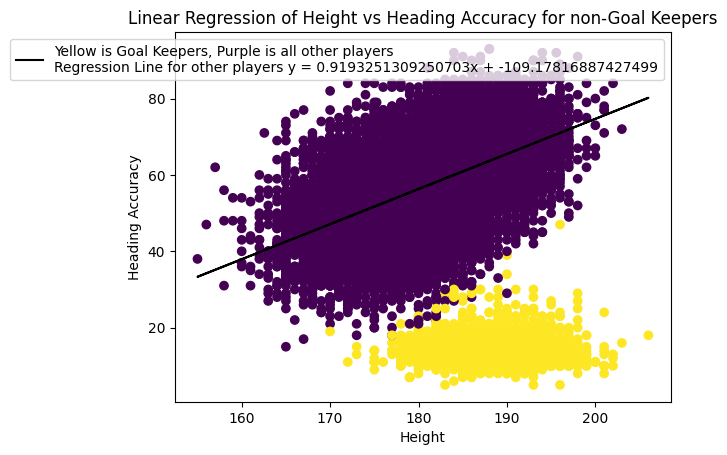

0.9193251309250703


In [78]:
# t-test on the slope coefficient of a simple linear regression between Height and Heading accuracy
df_other_players = df[df['Positions'] != 'GK']


x = df['Height'].values
y = df['Heading Accuracy'].values
colors = df['is_goal_keeper'].values

x_others = df_other_players['Height'].values
y_others = df_other_players['Heading Accuracy'].values
slope, intercept = np.polyfit(x_others,y_others,1)

plt.figure()

plt.scatter(x,y, c=colors)


y_pred = slope * x + intercept
lineText = "y = " + str(slope) + "x + " + str(intercept)
plt.plot(x, y_pred, c='black', label=f'Yellow is Goal Keepers, Purple is all other players \nRegression Line for other players {lineText}')
plt.legend()
plt.title("Linear Regression of Height vs Heading Accuracy for non-Goal Keepers")
plt.xlabel("Height")
plt.ylabel("Heading Accuracy")
plt.show()
print(slope)




In [79]:
import scipy.stats as stats
linModel = stats.linregress(x_others, y_others)

print("The p-value is " + str(linModel.pvalue))


The p-value is 0.0


**Conclusion:**
After creating a new dataframe that excluded goal keepers, I ran a regression with Height as my explanatory variable and Heading Accuracy as my response variable. The above graph emphasizes how important it was to take goal keepers out to actually test for a relationship. I was testing for if there was a statistically significant linear relationship between Height and Heading Accuracy. My p-value is 0, suggesting I reject the null hypothesis that the slope coefficient is 0. Thus, I can conclude that there is a statistically significant relationship between Height and Heading Accuracy, when you exclude Goal Keepers.

#### Player Age Compared to Stamina

Does a player's age have an effect on the amount of stamina they have?

H0: There is no significant difference in mean stamina across different age groups

HA: There is at least one group that has a significant difference in mean stamina across different age groups

Testing method: One-way ANOVA + Tukey HSD post-hoc

Here is documentation explaining how the Tukey HSD Test works for One-way ANOVA: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html

60.00706675364209
66.69430126002291
61.26993207007508
F-Statistic: 382.7538
P-Value: 0.0000
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1       group2   meandiff p-adj   lower   upper  reject
---------------------------------------------------------------
24_and_under    25_to_30   6.6872    0.0  6.1108  7.2637   True
24_and_under 31_and_over   1.2629 0.0005  0.4786  2.0471   True
    25_to_30 31_and_over  -5.4244    0.0 -6.2371 -4.6117   True
---------------------------------------------------------------


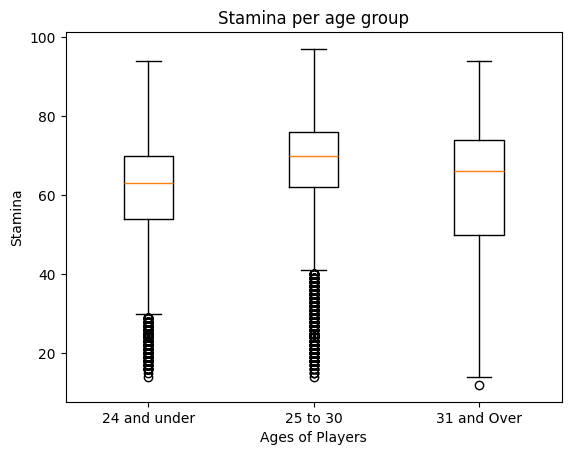

In [80]:
df_age_and_stamina = df.dropna(subset=['Stamina', 'Age'])

df_24_and_under = df_age_and_stamina[df_age_and_stamina['Age'] <= 24].copy()
df_25_to_30 = df_age_and_stamina[df_age_and_stamina['Age'].between(25, 30)].copy()
df_31_and_over = df_age_and_stamina[df_age_and_stamina['Age'] >= 31].copy()

df_24_and_under['Group'] = '24_and_under'
df_25_to_30['Group'] = '25_to_30'
df_31_and_over['Group'] = '31_and_over'

mean24 = df_24_and_under['Stamina'].mean()
mean25to30 = df_25_to_30['Stamina'].mean()
mean31 = df_31_and_over['Stamina'].mean()
print(mean24)
print(mean25to30)
print(mean31)

f_stat, p_value = stats.f_oneway(df_24_and_under['Stamina'], df_25_to_30['Stamina'], df_31_and_over['Stamina'])
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

df_combined = pd.concat([df_24_and_under, df_25_to_30, df_31_and_over])

tukey = pairwise_tukeyhsd(endog=df_combined['Stamina'], groups=df_combined['Group'], alpha=0.05)
print(tukey)

data = [df_24_and_under['Stamina'], df_25_to_30['Stamina'], df_31_and_over['Stamina']]

plt.boxplot(data, tick_labels=['24 and under', '25 to 30', '31 and Over'])
plt.xlabel('Ages of Players')
plt.ylabel('Stamina')
plt.title('Stamina per age group')
plt.show()


**Conclusion:** Since the p-value is less than the significant level 0.05, we reject the null hypothesis. That means there is significant correlation between age group and stamina. According to the Tukey HSD test, every age group has a significant difference in stamina as the p-value when comparing the individual groups with each other are all less than the significant level 0.05.


#### Left Footed versus Right Footed Players Performance


We will perform a two sample t test to see if the mean overall left foot dominant players is different than the mean overall of right foot dominant players with confidence a = 0.05

$μ_{left}$ is the mean overall of left foot dominant players that played in FIFA

$μ_{right}$ is the mean overall of right foot dominant players that played in FIFA

H0: $μ_{left}$ = $μ_{right}$

HA: $μ_{left}$ != $μ_{right}$

Here is documentation explaining how the Two Sample T Test works: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html


In [81]:
df = df.rename(columns={'↓OVA' : 'OVA'}) # get rid of special character in column name

from scipy import stats

# We will perform a two sample t test to see if the mean overall left foot dominant players
# is different than the mean overall of right  footdominant players with confidence a = 0.05

groups = df.groupby('Preferred Foot')['OVA']
left = groups.get_group('Left')
right = groups.get_group('Right')

t_stat, p_val = stats.ttest_ind(left, right, equal_var=False)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_val}")


print(f"Left foot mean OVA: {left.mean()}")
print(f"Right foot mean OVA: {right.mean()}")

T-statistic: 6.691734114597227
P-value: 2.3548224638814175e-11
Left foot mean OVA: 66.30524922805469
Right foot mean OVA: 65.53451021114573


Our P-Value is basically 0, which is < a = 0.05, which means we have statistically significant evidence to reject the null hypothesis.
This means there is a real difference in the mean OVA of left footed and right footed players. And since our left foot sample mean is greater than our right foot sample mean, we can conclude that left foot players have a higher overall on average. To see this, we will create a density plot of player OVA for left and right footed players overlaid on top of each other. The reason we use a density plot is that it normalizes the total number of people in each group so we can see the difference in OVA distribution more easily.

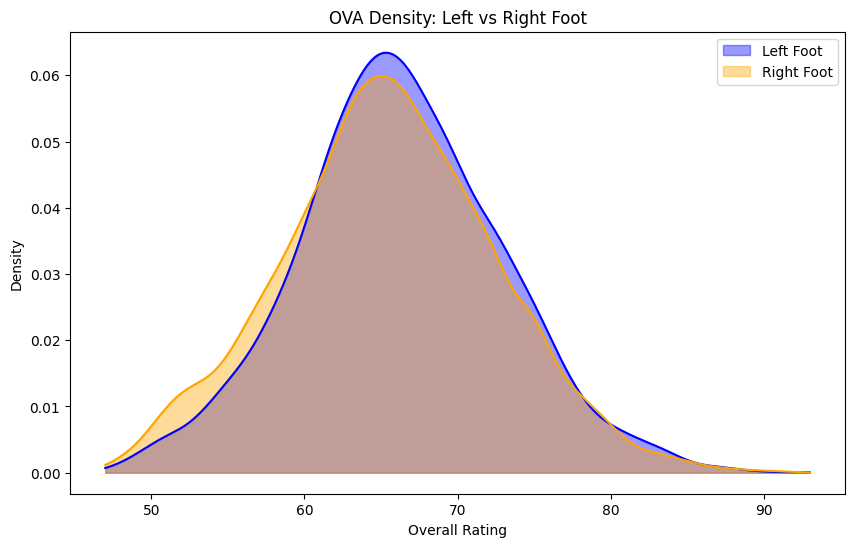

In [82]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(min(left.min(), right.min()), max(left.max(), right.max()), 500)

left_kde = stats.gaussian_kde(left)
right_kde = stats.gaussian_kde(right)

ax.fill_between(x, left_kde(x), alpha=0.4, color='blue', label='Left Foot')
ax.fill_between(x, right_kde(x), alpha=0.4, color='orange', label='Right Foot')
ax.plot(x, left_kde(x), color='blue')
ax.plot(x, right_kde(x), color='orange')

# Add mean bars
# left_mean = left.mean()
# right_mean = right.mean()
# ax.axvline(left_mean, color='blue', linestyle='--', linewidth=2,
#            label=f'Left mean ({left_mean:.1f})')
# ax.axvline(right_mean, color='orange', linestyle='--', linewidth=2,
#            label=f'Right mean ({right_mean:.1f})')

ax.set_xlabel('Overall Rating')
ax.set_ylabel('Density')
ax.set_title('OVA Density: Left vs Right Foot')
ax.legend()


**Conclusion:** P-Value is basically 0, which is less than a = 0.05, which means we have statistically significant evidence to reject the null hypothesis.
This means there is a real difference in  the mean OVA of left footed and right footed players

Since our left foot sample mean is greater than our right foot sample mean, we can conclude that left foot players have a higher overall on average.

<a id="d"></a>
## ML Algorithm Design/Development

#### Section Overview

In this section, we are doing a classification problem (classifying a player's position based on their attributes from FIFA21). We are setting up a dataset to use for training and testing our selected models. The features we used were all physical and skill-based attributes, such as pace, shooting, passing, dribbling, physicality, and other player ability metrics. Note that all features are numerical values from 0-99, while we have only one categorical feature "preferred foot" which had values "left" or "right".

We chose these features because they reflect the types of characteristics that may naturally influence where a player is positioned on the field. For example, forwards may tend to have stronger shooting and pace attributes, midfielders may have stronger passing and dribbling abilities, and defenders may show different physical or technical patterns. Using these attributes allows the model to learn position-related patterns based on a player’s overall profile.
We excluded features such as overall defensive rating and offensive rating because those variables are too direct of an indicator of a player’s position. Including them could make the classification task too obvious and would not align with the goal of our question.

To set up our dataset for training and testing, we first had to one hot encode the categorical features, which in our case was just the preferred foot. This is because for the ml model to better digest the features, changing them into 2 columns, one "right" and other "left" with a binary 1 (yes) and 0 (no) is a better format for the ml model. Additionally, we had to feature encode the positions label (our y) because like before, we need the model to be able to properly digest this feature. It was initially strings like "CB" and "ST", but we have changed them to 0-15 (# positions there are) so that the ml model can actually use this feature. The change from string to numerical value wouldn't influence any of the models either because all of the models we chose from skleanr use a multinomial solver, meaning that they treat the position labels as separate categories rather than as ordered numerical values.


In [83]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Define new features for classification
numerical_features = [
    # Physical / movement
    'Height',
    'Acceleration', 'Sprint Speed', 'Agility', 'Reactions', 'Balance',
    'Jumping', 'Stamina', 'Strength',

    # Attacking (maybe keep, might be too revealing)
    'Crossing', 'Finishing', 'Heading Accuracy', 'Short Passing',
    'Volleys', 'Dribbling', 'Curve', 'FK Accuracy', 'Long Passing',
    'Ball Control',

    # Defending (maybe keep, might be too revealing)
    'Marking', 'Standing Tackle', 'Sliding Tackle',

    # Shooting
    'Shot Power', 'Long Shots',

    # Mentality
    'Aggression', 'Interceptions', 'Positioning', 'Vision',
    'Penalties', 'Composure',

    # Goalkeeping
    'GK Diving', 'GK Handling', 'GK Kicking',
    'GK Positioning', 'GK Reflexes',
]
categorical_features = ['Preferred Foot']

# combine all features and we will drop nas incase we missed any at data cleaning
all_features = numerical_features + categorical_features + ['Best Position']
df_cleaned = df.dropna(subset = all_features).copy()

# Encode the target variable (since it is string --> "RB", "CB", "GK"...)
le = LabelEncoder()
df_cleaned['Position_encoded'] = le.fit_transform(df_cleaned['Best Position'])

# y true dataset
y = df_cleaned['Position_encoded']

# One-hot encode categorical features (preffered foot if "left" and "right")
X_foot = pd.get_dummies(df_cleaned[categorical_features], columns = categorical_features, drop_first = False)

# Combine numerical and one-hot encoded categorical features
X = pd.concat([df_cleaned[numerical_features], X_foot], axis = 1)

# 3. Define Classification Models
# Wrap distance-based models (LogReg, SVC) in a pipeline with StandardScaler
# Tree-based models don't need scaling
models = {
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(random_state = 42, max_iter = 1000)),
    'Decision Tree Classifier': DecisionTreeClassifier(random_state = 42),
    'Random Forest Classifier': RandomForestClassifier(random_state = 42),
    'Support Vector Classifier': make_pipeline(StandardScaler(), SVC())
}

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
print(f"Number of unique positions: {len(le.classes_)}")
print(f"Positions mapping: {list(le.classes_)}")

Shape of X: (18979, 37)
Shape of y: (18979,)
Number of unique positions: 15
Positions mapping: ['CAM', 'CB', 'CDM', 'CF', 'CM', 'GK', 'LB', 'LM', 'LW', 'LWB', 'RB', 'RM', 'RW', 'RWB', 'ST']


<a id="e"></a>
## ML Algorithm Training, Testing, and Analysis

Now that we have prepared our features, it is time to build a model. We will test 4 different models: Logistic regression, decision tree, random forest classifier, support vector machine (SVM) and compare their scores on various metrics with a focus on accuracy.

Here are links for more information on each model:  
[Logistic regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)  
[Decision tree (what it is)](https://scikit-learn.org/stable/modules/tree.html)
[Decision tree (python class)](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)  
[Random forest classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)  
[SVM (what it is)](https://scikit-learn.org/stable/modules/svm.html)  
[SVC (class that we use)](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)


Last minute check for missing values before creating training/testing datasets.

In [84]:
# Check for missing values in features and target
print("Missing values per feature:")
print(X.isna().sum()[X.isna().sum() > 0])  # only show columns with NaNs
print(f"\nMissing values in target (Best Position): {y.isna().sum()}")
print(f"\nTotal rows: {len(X)}")
print(f"Rows with any NaN: {X.isna().any(axis=1).sum()}")

# Drop rows with missing values in features or target
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

print(f"Rows remaining after dropping NaNs: {len(X)}")

Missing values per feature:
Series([], dtype: int64)

Missing values in target (Best Position): 0

Total rows: 18979
Rows with any NaN: 0
Rows remaining after dropping NaNs: 18979


We split 80% of our data for training and the remaining 20% for testing.

In [85]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

Now we train each model and evalute its accuracy

In [86]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Train and evaluate each model
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'accuracy': accuracy, 'predictions': y_pred}
    print(f"{name}: {accuracy:.4f}")

# Find the best model
best_name = max(results, key=lambda n: results[n]['accuracy'])
print(f"\nBest model: {best_name} with accuracy {results[best_name]['accuracy']:.4f}")

Logistic Regression: 0.8256
Decision Tree Classifier: 0.6486
Random Forest Classifier: 0.7824
Support Vector Classifier: 0.8177

Best model: Logistic Regression with accuracy 0.8256


Logistic Regression wins in accuracy with SVM closely behind.
We will perform 5-fold cross-validation rather than a single train/test split for more reliable accuracy estimates. Cross-validation trains and evaluates the model 5 times on different subsets of the data, providing both a mean accuracy and a standard deviation. Models with high mean accuracy and low standard deviation are most trustworthy.


In [87]:
from sklearn.model_selection import cross_val_score

# Evaluate each model with 5-fold cross-validation
print("==== 5-Fold Cross-Validation Results ====\n")
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_results[name] = {
        'mean_accuracy': scores.mean(),
        'std_accuracy': scores.std(),
        'all_scores': scores
    }
    print(f"{name}:")
    print(f"  Mean accuracy: {scores.mean():.4f}")
    print(f"  Std deviation: {scores.std():.4f}")
    print(f"  Per-fold scores: {[f'{s:.4f}' for s in scores]}\n")

# Identify best model
best_cv_name = max(cv_results, key=lambda n: cv_results[n]['mean_accuracy'])
print(f"Best model by 5-fold CV: {best_cv_name} ({cv_results[best_cv_name]['mean_accuracy']:.4f})")

==== 5-Fold Cross-Validation Results ====

Logistic Regression:
  Mean accuracy: 0.8261
  Std deviation: 0.0098
  Per-fold scores: ['0.8265', '0.8255', '0.8344', '0.8083', '0.8356']

Decision Tree Classifier:
  Mean accuracy: 0.6458
  Std deviation: 0.0104
  Per-fold scores: ['0.6553', '0.6516', '0.6526', '0.6268', '0.6426']

Random Forest Classifier:
  Mean accuracy: 0.7705
  Std deviation: 0.0065
  Per-fold scores: ['0.7758', '0.7642', '0.7754', '0.7612', '0.7760']

Support Vector Classifier:
  Mean accuracy: 0.8106
  Std deviation: 0.0045
  Per-fold scores: ['0.8113', '0.8064', '0.8166', '0.8047', '0.8142']

Best model by 5-fold CV: Logistic Regression (0.8261)


As we can see, Logistic Regression wins again with an average accuracy of 82.61% and a standard deviation of 0.0098. Let's visualize the performance of each model.

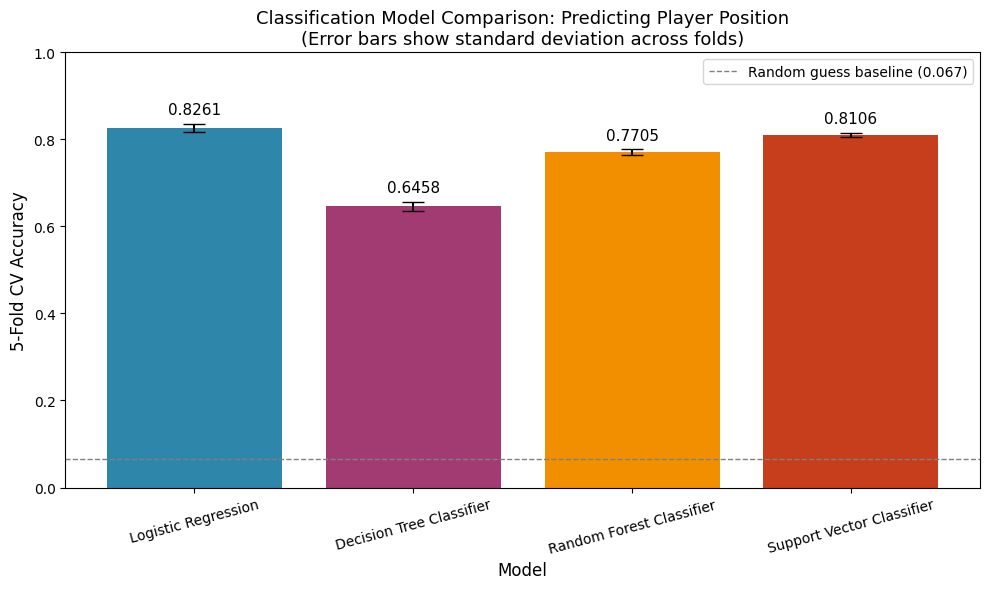

In [88]:
# Pull mean accuracies and std deviations from cross-validation results
model_names = list(cv_results.keys())
mean_accuracies = [cv_results[name]['mean_accuracy'] for name in model_names]
std_accuracies = [cv_results[name]['std_accuracy'] for name in model_names]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(model_names, mean_accuracies,
              yerr=std_accuracies, capsize=8,
              color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'],
              error_kw={'ecolor': 'black', 'elinewidth': 1.5})

# Add accuracy labels above each error bar
for bar, mean, std in zip(bars, mean_accuracies, std_accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + std + 0.015,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=11)

# Random baseline reference line (1 / number of classes)
baseline = 1 / len(le.classes_)
ax.axhline(y=baseline, color='gray', linestyle='--', linewidth=1,
           label=f'Random guess baseline ({baseline:.3f})')

ax.set_ylabel('5-Fold CV Accuracy', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_title('Classification Model Comparison: Predicting Player Position\n(Error bars show standard deviation across folds)', fontsize=13)
ax.set_ylim(0, 1.0)
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Let's look at the Logistic Regression in more detail

In [89]:
# Detailed look at the best model
best_predictions = results[best_name]['predictions']

print(f"Classification Report for {best_name}:\n")
print(classification_report(y_test, best_predictions))

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.79      0.82      0.80       458
           1       0.96      0.95      0.95       748
           2       0.81      0.85      0.83       308
           3       0.33      0.17      0.22         6
           4       0.78      0.74      0.76       215
           5       1.00      1.00      1.00       406
           6       0.72      0.79      0.75       224
           7       0.63      0.52      0.57       168
           8       0.11      0.03      0.04        36
           9       0.56      0.20      0.29        51
          10       0.67      0.80      0.73       224
          11       0.67      0.77      0.72       333
          12       0.33      0.14      0.20        56
          13       0.35      0.15      0.21        52
          14       0.93      0.97      0.95       511

    accuracy                           0.83      3796
   macro avg       0.64      0.5

Let's also look at the confusion matrix to see if we can gain any insights.

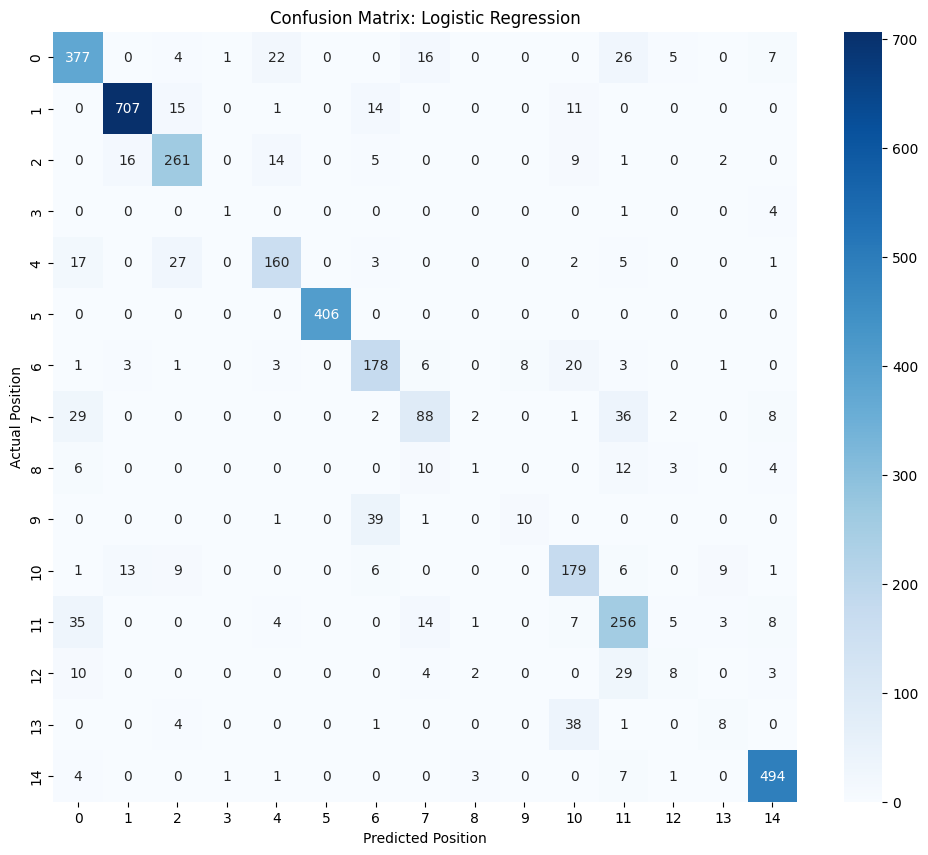

In [90]:
# Confusion matrix for the best model
labels = sorted(y.unique())
cm = confusion_matrix(y_test, best_predictions, labels=labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Position')
plt.ylabel('Actual Position')
plt.title(f'Confusion Matrix: {best_name}')
plt.show()

Here's the positions, for reference:

['CAM (0)', 'CB (1)', 'CDM (2)', 'CF (3)', 'CM (4)', 'GK (5)', 'LB (6)', 'LM (7)', 'LW (8)', 'LWB (9)', 'RB (10)', 'RM (11)', 'RW (12)', 'RWB (13)', 'ST (14)']

Some immediate takeaways from the classification report and confusion matrix is that the Logistic Regression generally performs well overall, but does not for positions 3, 8, 12, and 13, which correspond to CF (Center Forward), LW (Left Wing), RW (Right Wing), and RWB (Right-Wing Back).

For position 3 (CF), there appear to just be very few data points in general.

For position 8 (LW), most most players who are miscategorized are put as position 11 (RM) or position 7 (LM).

For position 12 (RW), players are largely miscategorized as position 11 (RM), which I guess makes some sense since they both operate on the right flank.

For position 13 (RWB) players are overwhelmingly miscategorized as position 10 (RB), which makes sense because they are very similar positions.

Looking at these different positions our model performed fairly poorly with, it's very notable that these are positions that we don't have lot of players for, especially compared to the other positions. This makes sense, because if our model has a lot of data for players of fairly similar positions but not that position, training the model might reward it for choosing those other positions more often because they make up a larger share of our training data. This is often referred to as the 'Majority Rule Bias'.

<a id="f"></a>
## Identifying most important coefficients

Because we have 15 different positions, we're generating a logistic regression model for each position. This means our coefficients forms a 2D array, with a vector of coefficients for each position. By changing pos_index, we can choose the position model we're looking at, and sort to identify the most important features/coefficients (by magnitude) for that position.

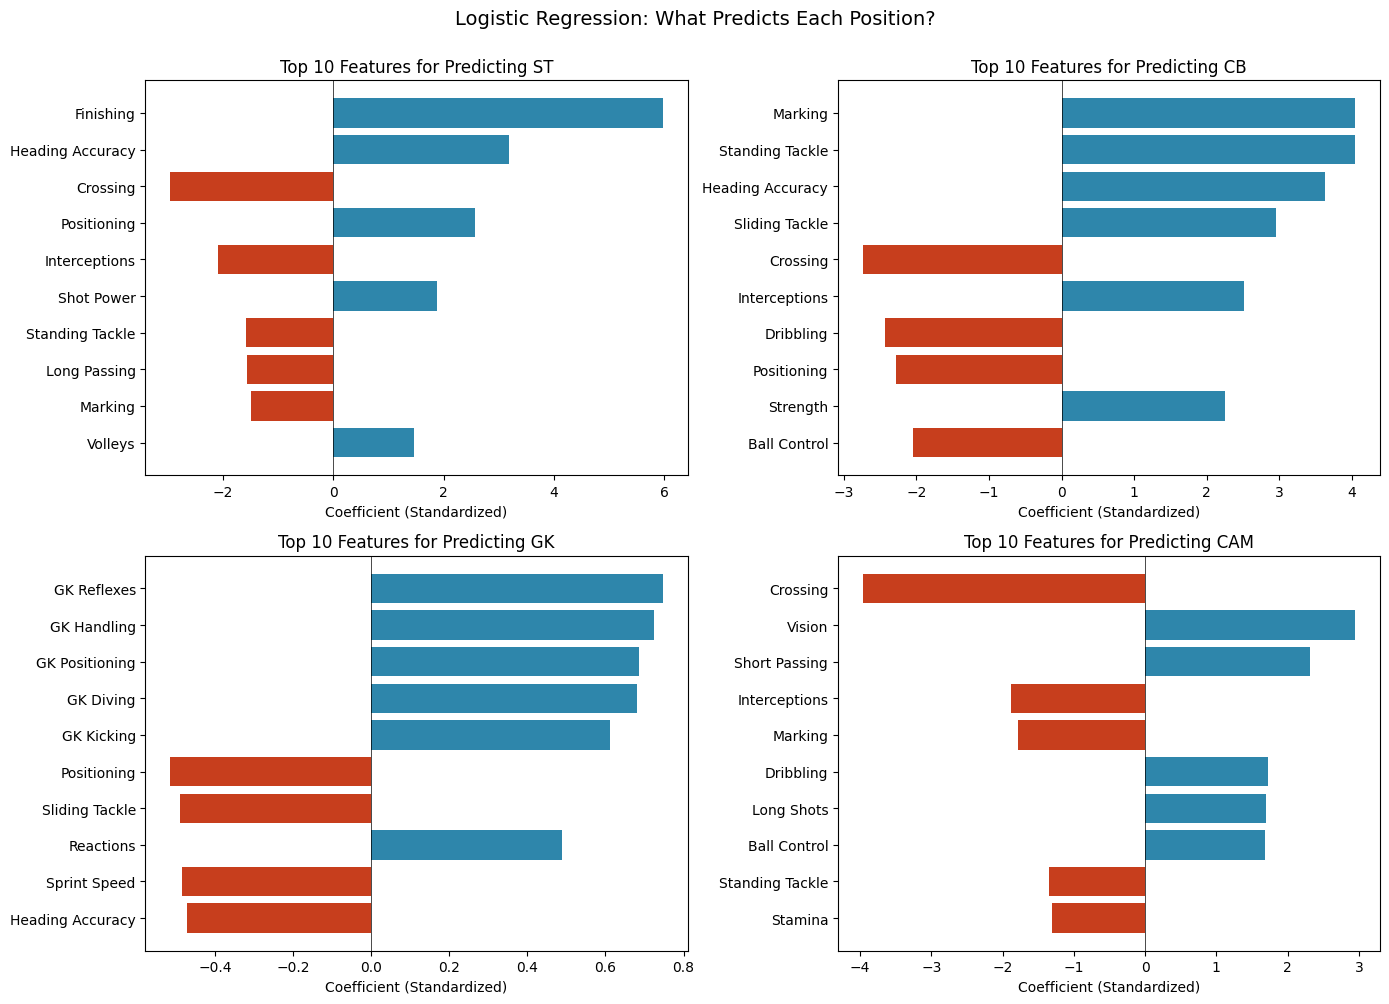

In [91]:
# Get the fitted Logistic Regression pipeline
logreg_pipeline = results['Logistic Regression']['model']
logreg = logreg_pipeline.named_steps['logisticregression']

# Pick a few interesting positions to visualize
positions_to_plot = ['ST', 'CB', 'GK', 'CAM']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, pos in enumerate(positions_to_plot):
    if pos not in le.classes_:
        continue

    pos_idx = list(le.classes_).index(pos)
    coefs = logreg.coef_[pos_idx]
    feature_names = X.columns

    # Get top 10 features by absolute coefficient value
    top_idx = np.argsort(np.abs(coefs))[-10:]
    top_features = [feature_names[j] for j in top_idx]
    top_coefs = coefs[top_idx]

    # Color positive and negative differently
    colors = ['#2E86AB' if c > 0 else '#C73E1D' for c in top_coefs]

    axes[i].barh(range(len(top_features)), top_coefs, color=colors)
    axes[i].set_yticks(range(len(top_features)))
    axes[i].set_yticklabels(top_features, fontsize=10)
    axes[i].axvline(x=0, color='black', linewidth=0.5)
    axes[i].set_title(f'Top 10 Features for Predicting {pos}', fontsize=12)
    axes[i].set_xlabel('Coefficient (Standardized)')

plt.suptitle('Logistic Regression: What Predicts Each Position?', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

<a id="g"></a>
## Insights and Conclusions

This project attempts to answer four different research questions regarding FIFA 21 players: how height affects technical heading skills, how age affects stamina, whether a preferred foot influences overall rating, and if only a player's attributes can be a predictor for their position on the field.

Our linear regression on height vs. heading accuracy (excluding goalkeepers) returned a statistically significantly positive slope, but the effect size was small. Taller players have a modest advantage in heading, but the relationship only explains a small fraction of the variance. Height itself is not that great of a predictor for heading accuracy.

We found a statistically significant negative correlation between age and stamina. Older players 31 years and older tend to have lower stamina ratings, which is typically observed in real soccer as well.

A two sample t-test showed that left-footed players have a slight but significantly higher overall mean than right-footed players. This is an interesting discovery. A possible reason why is because left-footed players are more rare and the ones who do make it to the professional level tend to be more technically developed.

To address whether a player's attributes can identify their position on the field, we framed this as a classification problem and tried to classify each player within 1 of 15 positions on the field. We only used specific skill traits, deliberately excluding FIFA's summaries (PAC	SHO	PAS	DRI	DEF	PHY) of the players because they often give away the position of the player. We compared the performance of 4 different models (Logistic Regression, Decision Tree, Random Forest, and Support Vector Classifier). Logistic Regression performed the best with an accuracy of 82.6%, which is well above trying to randomly guess the position. This suggests that a player's attributes carries substantial information about their role on the field.

The pattern of errors that the model made was very interesting. The model is able to classify goalkeepers and centerbacks perfectly. But it had difficulty determining if a player was a winger or wide midfielder. It also confused wing-backs with full-backs. These mis-classifications tell us that the distinction between positions are sometimes from the assignments of the coaches rather than a player's attributes.

Physical attributes and skill ratings explain most of what determines a player's position, but not all of it. Some roles are clearly defined by a player's attributes while others may be determined by the coach's scheme. For a reader new to soccer analytics, this is a reminder that data captures most but not all of what defines a player on the field. For those who are familiar with soccer and analytics, this is a  confirmation that the difference between a player being two similar positions, (ex: a left winger or left midfielder) is more determined by the tactics of the team's playstyle and less about individual skillset.